In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-build graph. In this case the WECC example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

In [43]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_capacity'] = 0

In [72]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.13992738723754883
Variables Built: 0.10784792900085449
Constraints Built: 0.9736666679382324
Objective Built: 0.39914417266845703


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32760, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32760), overall = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32760, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32760), warning = Bunch(unassociated_disjuncts = 0))

In [73]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 4.63332200050354
Results Collected: 0.03316974639892578


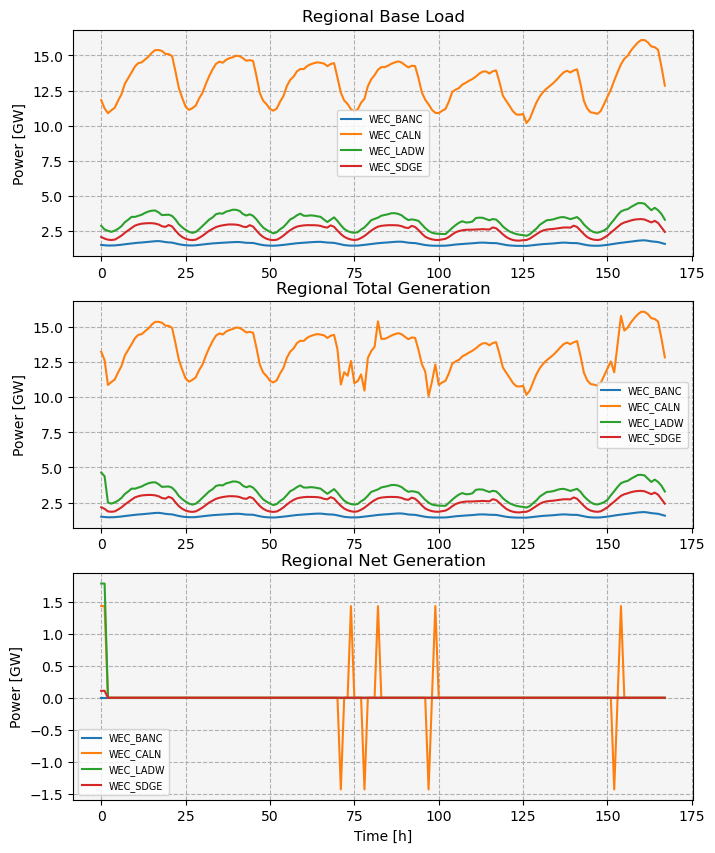

In [74]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():
    if 'assets' in results[source]:

        ax[0].plot(
            -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
            label = source,
        )
        
        ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
        )

        ax[1].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items()]
        )

        ax[2].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[2].set_title('Regional Net Generation')
        ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

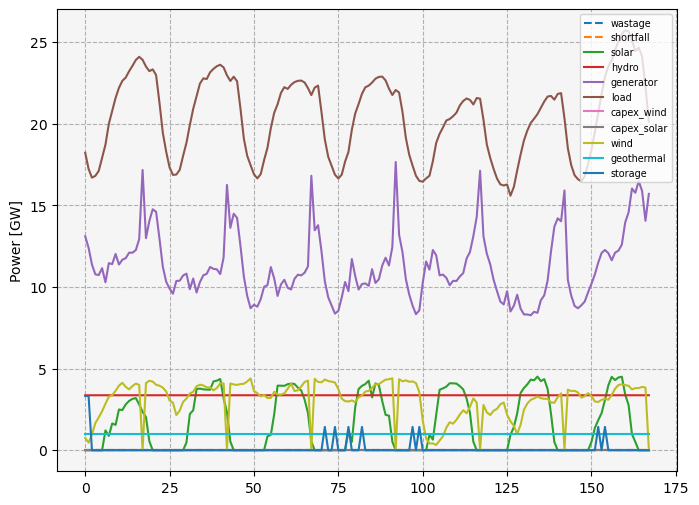

In [75]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

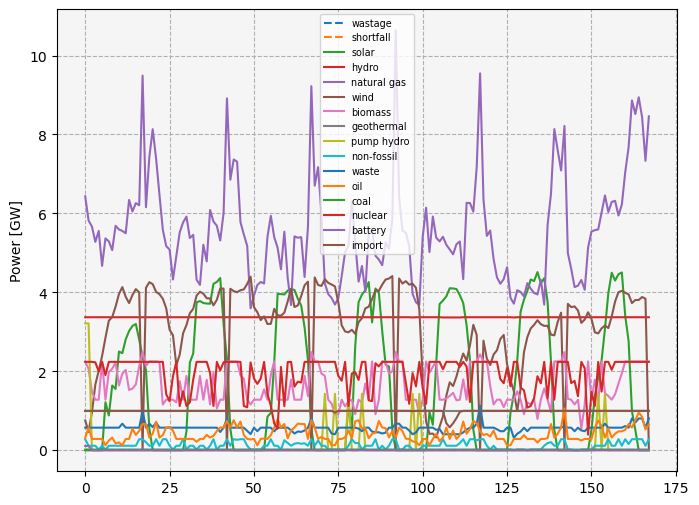

In [76]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            'steps': 24 * 7,

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

In [77]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

In [78]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.13283896446228027
Variables Built: 0.11116647720336914
Constraints Built: 1.0501408576965332
Objective Built: 0.22482800483703613


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32865, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32865), overall = Bunch(binary_variables = 0, constraints = 59976, continuous_variables = 32865, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32865), warning = Bunch(unassociated_disjuncts = 0))

In [79]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 1.8297274112701416
Results Collected: 0.033522605895996094


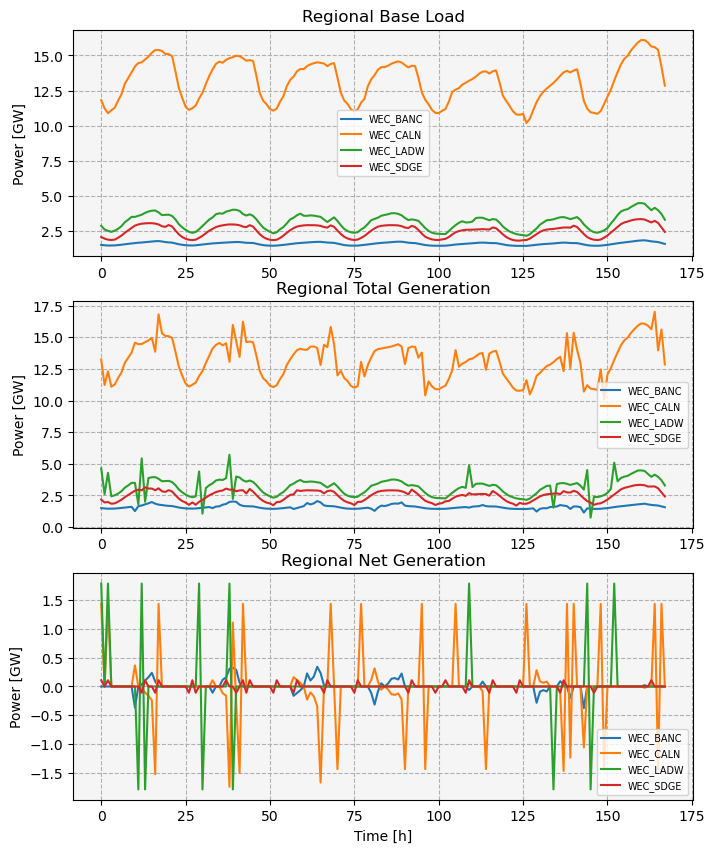

In [80]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

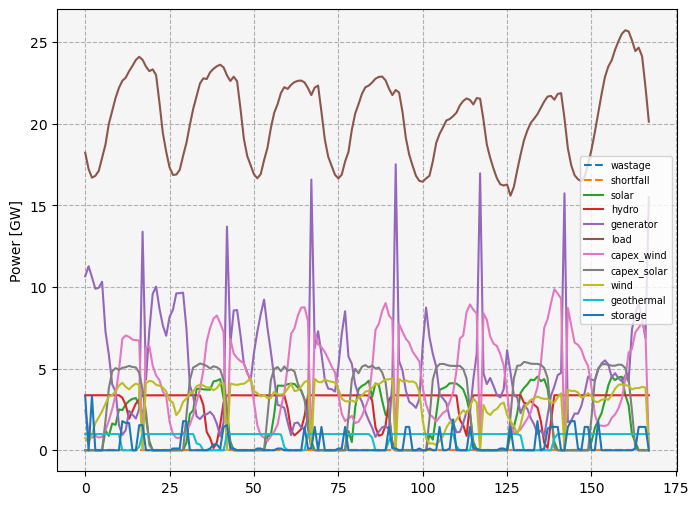

In [81]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

In [82]:
'''
Loading graph and policies - with shifable base load
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):
        
        if asset['type'] == 'load':

            asset['shift_portion'] = .5

In [83]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.13573765754699707
Variables Built: 0.11896300315856934
Constraints Built: 1.1121289730072021
Objective Built: 0.22449183464050293


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 60652, continuous_variables = 33537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 33537), overall = Bunch(binary_variables = 0, constraints = 60652, continuous_variables = 33537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 33537), warning = Bunch(unassociated_disjuncts = 0))

In [84]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 1.31748628616333
Results Collected: 0.033243417739868164


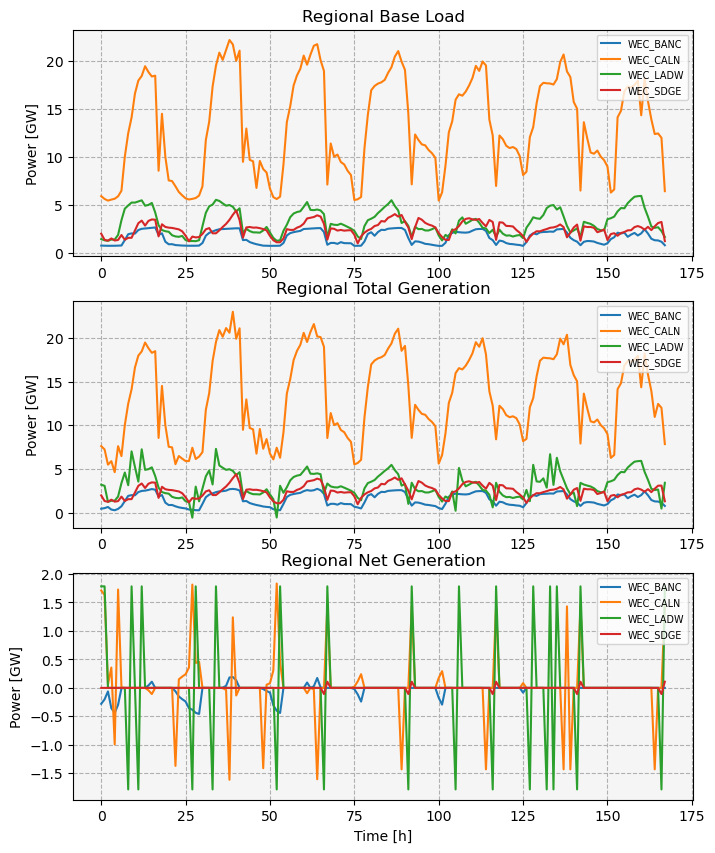

In [85]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():
    if 'assets' in results[source]:

        ax[0].plot(
            -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
            label = source,
        )
        
        ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
        )

        ax[1].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items()]
        )

        ax[2].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[2].set_title('Regional Net Generation')
        ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

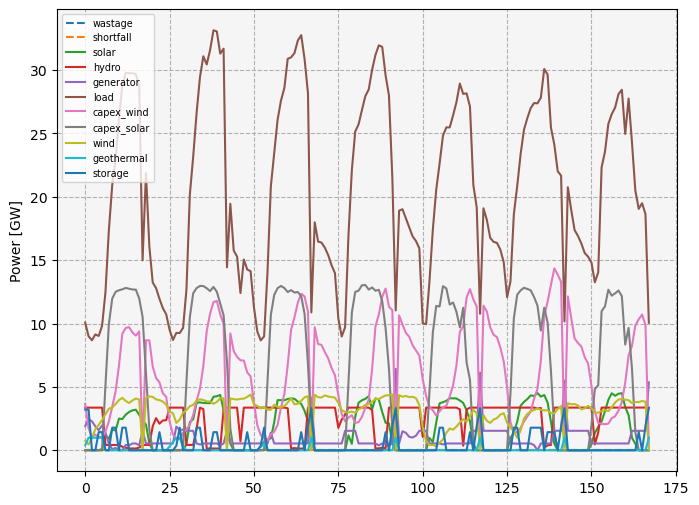

In [86]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

In [24]:
graph.nodes

NodeView(('WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY', 'WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE'))

In [29]:
california = ['WEC_SDGE', 'WEC_LADW', 'WEC_BANC', 'WEC_CALN']

[a['installed_capacity'] / 1e6 for n in california for a in graph._node[n]['assets'] if a['type'] == 'wind']

[1151.78, 953.98, 3280.968391]

In [31]:
california = graph.nodes

sum(
    [a['installed_capacity'] / 1e6 for n in california for a in graph._node[n]['assets'] if a['type'] == 'wind']
)

29336.702706771